# Imports

In [1]:
from data import *
from models import *
from optim import *
from results_utils import *
from scripts import *
from trainer import *

In [2]:
OPTIMIZE = False
VAL_SIZE = 48
TRAINING = True
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Using device: {DEVICE}")


Using device: mps


# Load data

In [3]:
print("Loading WEAVE data...")
print("="*60)

X_train, y_train = load_weave_data(
    "data/train_weave3.csv",
    node_col="id_unique",
    y_col="consumption",
    feature_prefix="consumption_l",
    drop_cols=["Unnamed: 0"],
)

X_test, y_test = load_weave_data(
    "data/test_weave3.csv",
    node_col="id_unique",
    y_col="consumption",
    feature_prefix="consumption_l",
    drop_cols=["Unnamed: 0"],
)

# Get common nodes
nodes_train = set(X_train.keys())
nodes_test = set(X_test.keys())
nodes = sorted(nodes_train & nodes_test)

print("="*60)
print(f"Train nodes: {len(nodes_train)}")
print(f"Test nodes: {len(nodes_test)}")
print(f"Common nodes: {len(nodes)}")

# Summary statistics
train_sizes = [len(y_train[v]) for v in nodes]
test_sizes = [len(y_test[v]) for v in nodes]
print(f"Train samples per node: min={min(train_sizes)}, max={max(train_sizes)}, mean={np.mean(train_sizes):.1f}")
print(f"Test samples per node: min={min(test_sizes)}, max={max(test_sizes)}, mean={np.mean(test_sizes):.1f}")
print(f"Feature dimension: {X_train[nodes[0]].shape[1]}")

Loading WEAVE data...
Using 'id_unique' as node identifier
Unique nodes: 100
Sorted by 'id_unique' and 'date'
Using 54 feature columns
Target column: 'consumption'
Loaded 100 nodes
Using 'id_unique' as node identifier
Unique nodes: 100
Sorted by 'id_unique' and 'date'
Using 54 feature columns
Target column: 'consumption'
Loaded 100 nodes
Train nodes: 100
Test nodes: 100
Common nodes: 100
Train samples per node: min=528, max=528, mean=528.0
Test samples per node: min=192, max=192, mean=192.0
Feature dimension: 54


# Optimization 

In [4]:
# Split training data into training and validation sets
X_train_n, y_train_n = {}, {}
X_val_n, y_val_n = {}, {}
X_test_n = {}
node_stats = {}

for v in nodes:
    Xn, yn, stats = normalize_xy(X_train[v], y_train[v])
    node_stats[v] = stats

    X_val_n[v], y_val_n[v] = Xn[:VAL_SIZE], yn[:VAL_SIZE]
    X_train_n[v], y_train_n[v] = Xn[VAL_SIZE:], yn[VAL_SIZE:]

    X_test_n[v] = (X_test[v] - stats["X_mean"]) / stats["X_std"]

# Select global root
global_root = select_seed_node(X_train, y_train)

tree_config = {
    "seed": global_root,
}

B = 1000

model_class = "linear"
cascade_config = {
    "B": B,
    "device": DEVICE,
    "model_class": model_class,
}

optim_space = {
    "eta": ("loguniform", 0.001, 0.1),
    "b_proto_frac": ("uniform", 0.1, 0.9),
}

global_mse = lambda mses: float(np.mean(list(mses.values())))
optimizer = OptunaCascadeOptimizer(
    eval_fn=global_mse,
    optim_space=optim_space,
    n_trials=200,
    seed=42,
)

if OPTIMIZE:
    print("\n" + "=" * 60)
    print("Running Optimization")
    print("=" * 60)
    best_params = optimizer.run(
        build_tree_fn=build_mst_tree,
        cascade_train_fn=cascade_train_tree,
        evaluate_models_fn=lambda models: evaluate_on_validation(models, X_val_n, y_val_n, node_stats),
        base_tree_kwargs={
            "V": nodes,
            "y": {v: y_train_n[v].flatten() for v in nodes},
            **tree_config,
        },
        base_cascade_kwargs={
            "X_train_n": X_train_n,
            "y_train_n": y_train_n,
            **cascade_config,
        },
        B=B,
        model_class=model_class,
    )

# Experiments

In [5]:
if TRAINING:
    # Run experiments
    print("\n" + "=" * 60)
    print("Running Experiments")
    print("=" * 60)

    ## low budget (150)
    # linear:   [Optuna] Best params: {'eta': 0.002019785769807688, 'b_proto_frac': 0.31056205255955316, 'ball_top_q': 0.5175687581510423} (val loss=5188.2081)
    # residual: {'eta': 0.0010012078005753858, 'b_proto_frac': 0.571549804487921, 'ball_top_q': 0.7810980222357717, 'eps': 0.12939078265739376, 'hidden': 37}
    # mlp:      {'eta': 0.002051110418843397,  'b_proto_frac': 0.14646688973455957, 'ball_top_q': 0.7929409166199481, 'eps': 0.3045463557541723, 'hidden': 96}
    
    ## high budget (1000)
    # linear:   [Optuna] Best params: {'eta': 0.001145703339166324, 'b_proto_frac': 0.16673617289851803} (val loss=5267.2429)
    # residual: [Optuna] Best params: {'eta': 0.001658570658409, 'b_proto_frac': 0.22324612106414812, 'eps': 0.03858324368183305, 'hidden': 52} (val loss=5195.8196)

    
    weave_results = run_experiment_grid(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        Bs=[1000],
        etas=[0.001145703339166324],
        b_proto_fracs=[.16673617289851803, 0.8],
        n_repeats=3,
        n_clusters=3,
        model_class='linear',
        mst_distance_types=["gradient", "model", "kl"],
        source_mode="medoid",
    )

    print("\n" + "=" * 60)
    print("Done!")
    print("=" * 60)


Running Experiments

Experiment Configuration
Nodes: 100
Budgets: [1000]
Learning rates: [0.001145703339166324]
Seed fractions: [0.16673617289851803, 0.8]
Repeats per config: 3
Model: linear
MST variants: ['gradient', 'model', 'kl']
Task clusters: 3
Source mode: medoid
Device: mps


Config 1/2
B=1000, eta=0.0011, b_proto_frac=0.167

Repeat 1/3
  Running Global MTL...
  Running Individual...
  Running Star...
  Running Random Tree...
  Running Cluster + Star...
  Running Cluster + MST...
  Running MST variants...
 done

Repeat 2/3
  Running Global MTL...
  Running Individual...
  Running Star...
  Running Random Tree...
  Running Cluster + Star...
  Running Cluster + MST...
  Running MST variants...
 done

Repeat 3/3
  Running Global MTL...
  Running Individual...
  Running Star...
  Running Random Tree...
  Running Cluster + Star...
  Running Cluster + MST...
  Running MST variants...
 done

  Global MTL: 1239.7372 ± 7.1311
  Indiv: 2718.7283 ± 37.9001 | Star: 1862.4437 ± 152.8023 | R

In [6]:
latex_str, df = weave_results_to_latex(weave_results, metric="rmse", 
                                       caption=r'Test RMSE (kWh) across global budgets $B$ and seed budget $b_{seed}$ on the UK electricity dataset. Each configuration is evaluated under five strategies across $50$ simulations, \textbf{bold} and \underline{underlined} entries denote best and second-best performance. Alignment-based CTL variants provide the most robust improvements across all settings.')
print(latex_str)
with open("results_weave4_.tex", "w") as f:
    f.write(latex_str)

\begin{table}[h]
\centering
\caption{Test RMSE (kWh) across global budgets $B$ and seed budget $b_{seed}$ on the UK electricity dataset. Each configuration is evaluated under five strategies across $50$ simulations, \textbf{bold} and \underline{underlined} entries denote best and second-best performance. Alignment-based CTL variants provide the most robust improvements across all settings.}
\label{tab:weave_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c|ccccccccc}
\toprule
$B$ & Indiv & Star & CTL-RandTree & cluster\_mst & cluster\_star & global\_mtl & CTL-MST-gradient & CTL-MST-kl & CTL-MST-model \\
\midrule
1000 & $2718.728 \pm 37.900$ & $1862.444 \pm 152.802$ & $1734.657 \pm 100.669$ & $1632.382 \pm 6.677$ & $1679.500 \pm 62.166$ & $\mathbf{1239.737 \pm 7.131}$ & $1812.464 \pm 153.088$ & $1626.412 \pm 27.541$ & $\underline{1559.707 \pm 23.055}$ \\
1000 & $2676.088 \pm 23.743$ & $1291.380 \pm 19.440$ & $1310.256 \pm 6.263$ & $\underline{1273.431 \pm 7.488}$ & $1276.719 \pm 4.

Renamed columns: {'indiv_mean': 'indiv_rmse_mean', 'indiv_se': 'indiv_rmse_se', 'star_mean': 'star_rmse_mean', 'star_se': 'star_rmse_se', 'random_mean': 'random_rmse_mean', 'random_se': 'random_rmse_se', 'cluster_mst_mean': 'cluster_mst_rmse_mean', 'cluster_mst_se': 'cluster_mst_rmse_se', 'cluster_star_mean': 'cluster_star_rmse_mean', 'cluster_star_se': 'cluster_star_rmse_se', 'global_mtl_mean': 'global_mtl_rmse_mean', 'global_mtl_se': 'global_mtl_rmse_se', 'mst_gradient_mean': 'mst_gradient_rmse_mean', 'mst_gradient_se': 'mst_gradient_rmse_se', 'mst_kl_mean': 'mst_kl_rmse_mean', 'mst_kl_se': 'mst_kl_rmse_se', 'mst_model_mean': 'mst_model_rmse_mean', 'mst_model_se': 'mst_model_rmse_se'}
{'indiv_mean': 'indiv_rmse_mean', 'indiv_se': 'indiv_rmse_se', 'star_mean': 'star_rmse_mean', 'star_se': 'star_rmse_se', 'random_mean': 'random_rmse_mean', 'random_se': 'random_rmse_se', 'cluster_mst_mean': 'cluster_mst_rmse_mean', 'cluster_mst_se': 'cluster_mst_rmse_se', 'cluster_star_mean': 'cluster_s

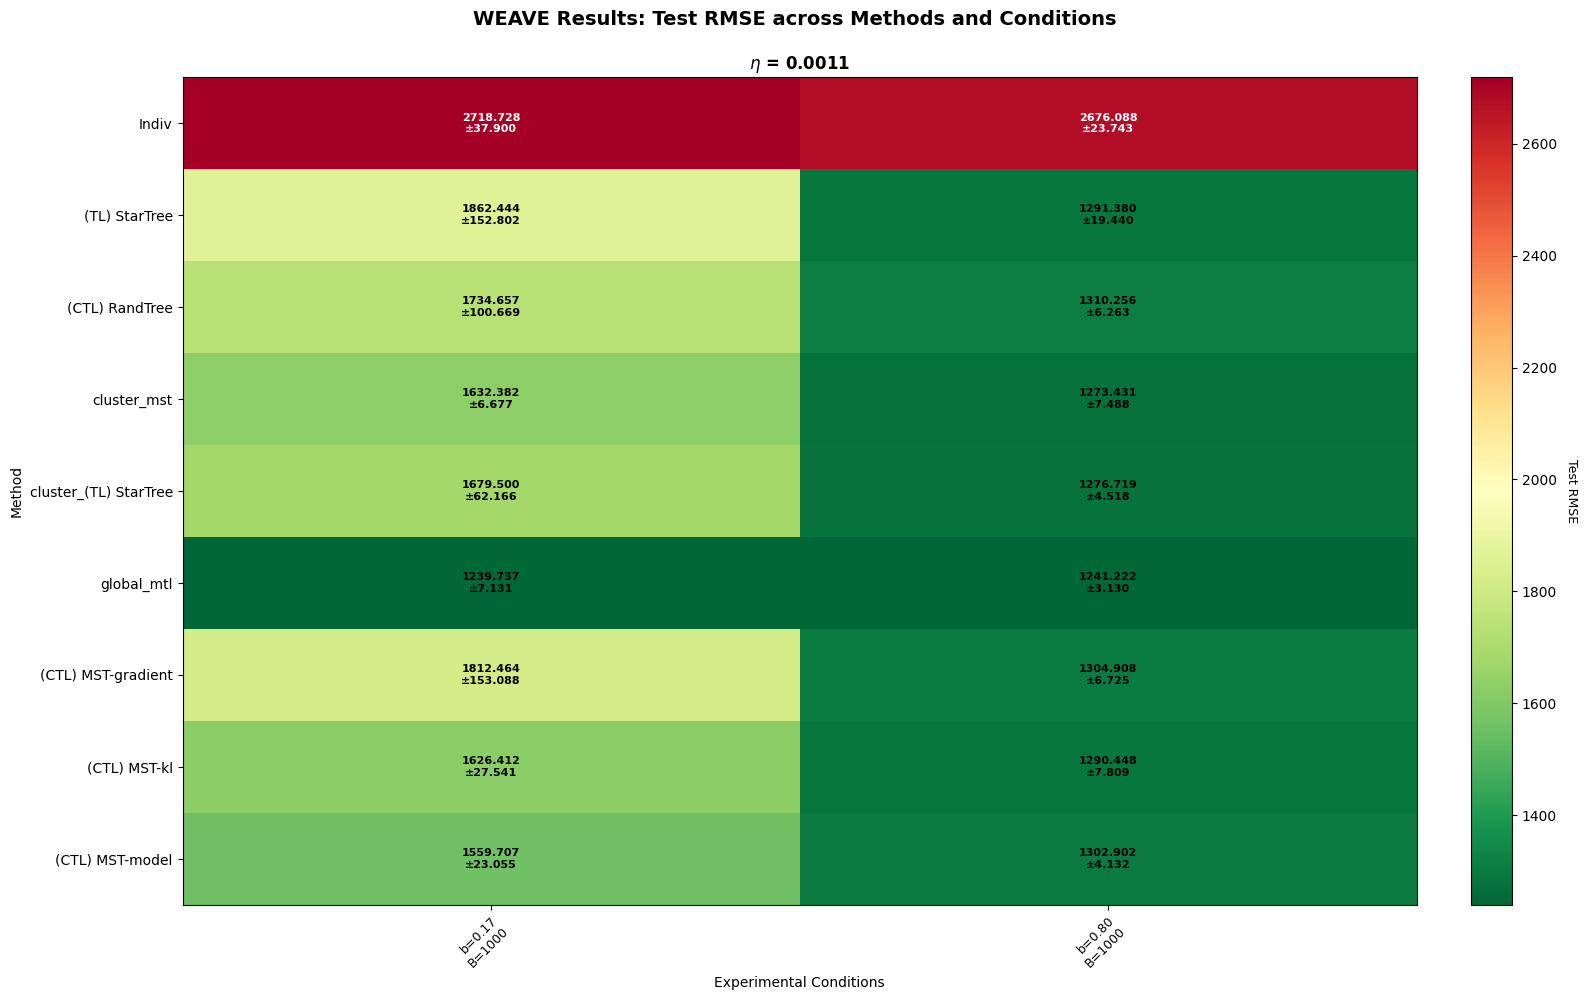

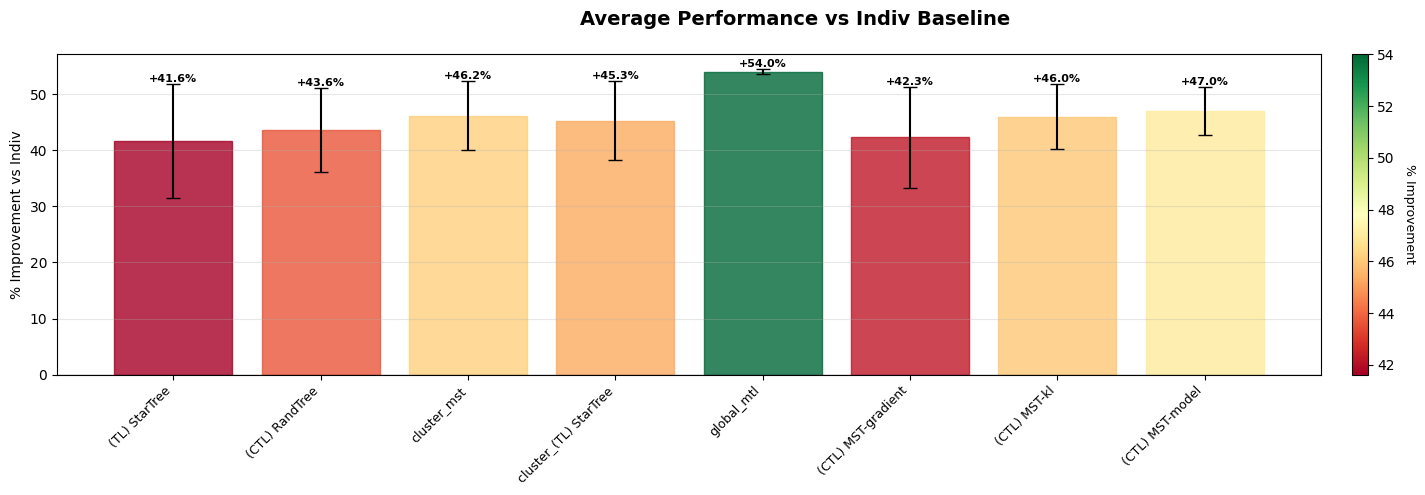

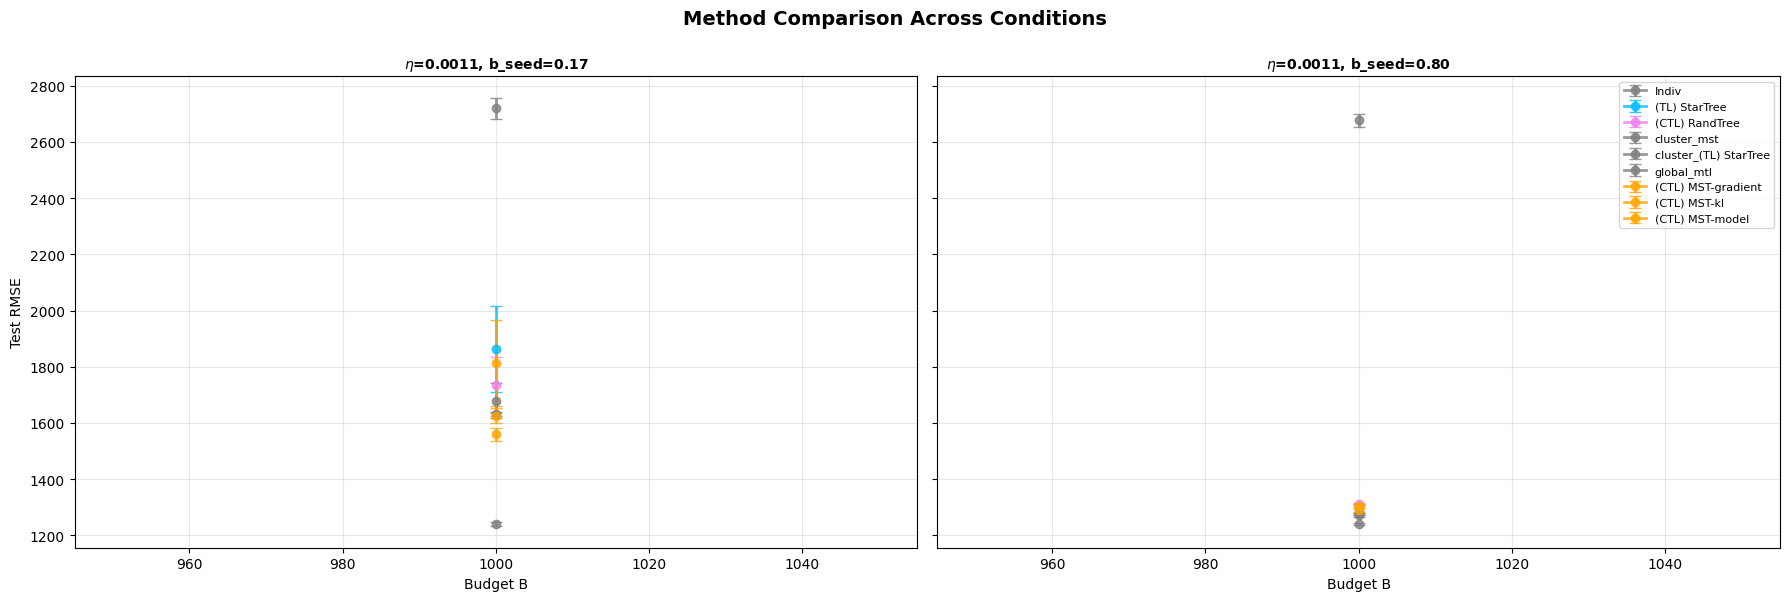

In [7]:
metric = "rmse"

# rename columns like 'indiv_mean' -> 'indiv_rmse_mean', 'indiv_se' -> 'indiv_rmse_se'
rename_map = {}
for c in df.columns:
    if c.endswith("_mean") and not c.endswith(f"_{metric}_mean"):
        base = c[:-len("_mean")]
        rename_map[c] = f"{base}_{metric}_mean"
    if c.endswith("_se") and not c.endswith(f"_{metric}_se"):
        base = c[:-len("_se")]
        rename_map[c] = f"{base}_{metric}_se"
if rename_map:
    df = df.rename(columns=rename_map)
    print("Renamed columns:", rename_map)

print(rename_map)
# detect methods from new column names
method_names = []
for c in df.columns:
    if c.endswith(f"_{metric}_mean"):
        method_names.append(c[: -len(f"_{metric}_mean")])
method_names = sorted(set(method_names))
method_names = [m for m in method_names if "align" not in m.lower()]

# prefer StarTree and CTL-RandTree first
preferred_first = ["indiv", "star", "random"]
ordered = []
for p in preferred_first:
    if p in method_names:
        ordered.append(p)
for m in method_names:
    if m not in ordered:
        ordered.append(m)
method_names = ordered

print("Detected methods (ordered):", method_names)

# build colors
colors = {}
for m in method_names:
    if m.startswith("mst_"):
        colors[m] = "orange"
    elif m == "indiv":
        colors[m] = "gray"
    elif m == "star":
        colors[m] = "deepskyblue"
    elif m == "random":
        colors[m] = "violet"
    else:
        colors[m] = "gray"

etas = sorted(df['eta'].unique())
b_proto_fracs = sorted(df['b_proto_frac'].unique())
Bs = sorted(df['B'].unique())

# call visualizers (examples)
fig, axes = visualize_weave_results_table(
    df=df, methods=method_names, etas=tuple(etas),
    b_proto_fracs=tuple(b_proto_fracs), Bs=tuple(Bs),
    colors=colors, metric=metric, show_std=True
)
plt.show()

fig, axes = visualize_weave_results_bars(
    df=df, methods=method_names, etas=tuple(etas),
    b_proto_fracs=tuple(b_proto_fracs), Bs=tuple(Bs),
    colors=colors, baseline="indiv", metric=metric
)
plt.savefig("weave_results_bars.pdf", dpi=300)
plt.show()

fig, axes = visualize_weave_results_comparison(
    df=df, methods=method_names, etas=tuple(etas),
    b_proto_fracs=tuple(b_proto_fracs), Bs=tuple(Bs),
    colors=colors, metric=metric
)
plt.show()

# CTL Comparison Figure (Indiv vs Star vs CTL-MSt)

Using k values - root: 10, internal: 10, leaf: 10


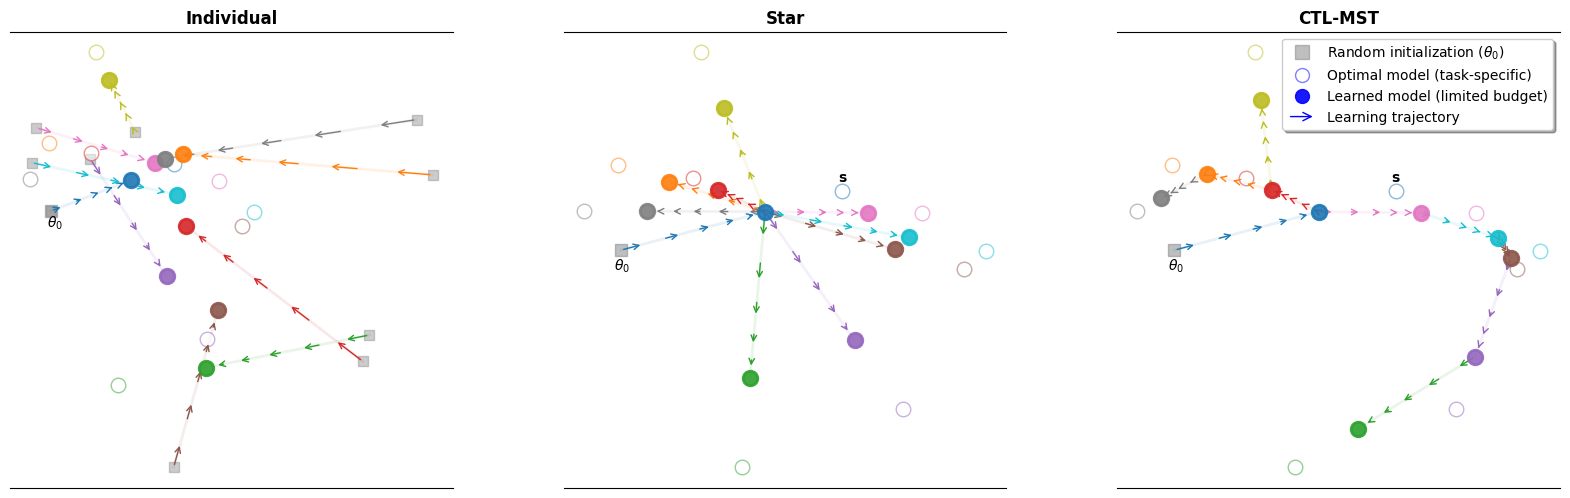

Root: 0
MST-target edges: [('0', '6'), ('6', '9'), ('9', '5'), ('0', '3'), ('3', '1'), ('1', '7'), ('1', '8'), ('5', '4'), ('4', '2')]
MST-gradient edges: [('0', '8'), ('8', '3'), ('3', '1'), ('1', '7'), ('0', '6'), ('6', '9'), ('9', '5'), ('5', '4'), ('4', '2')]
MST-wasserstein edges: [('0', '6'), ('6', '9'), ('9', '5'), ('0', '3'), ('3', '1'), ('1', '7'), ('3', '8'), ('5', '4'), ('4', '2')]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as rnd
from scipy.stats import wasserstein_distance

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import FancyArrowPatch

np.random.seed(4)

eta = 0.1
k_total = 100
alpha = eta / (2 * (1 - eta))
eps = 1e-9
tau = 100
num_nodes = 10
Y = {
    str(i) : rnd.normal(loc=0.0, scale=tau, size=(2,))
    for i in range(num_nodes)
}
V = list(Y.keys())
root = min(V, key=lambda v: sum(np.linalg.norm(Y[v] - Y[u]) for u in V))
theta0 = rnd.normal(loc=0.0, scale=tau, size=(2,))

def dist_target(u, v):
    """Target distance: Euclidean norm between target vectors"""
    return float(np.linalg.norm(Y[u] - Y[v]))

def dist_gradient(u, v):
    """Gradient distance: normalized gradient similarity proxy"""
    gu = Y[u] / (np.linalg.norm(Y[u]) + 1e-8)
    gv = Y[v] / (np.linalg.norm(Y[v]) + 1e-8)
    return float(np.linalg.norm(gu - gv))

def dist_kl(u, v):
    """KL divergence between 1D target distributions"""
    def kl_1d(p, q):
        p_var = 1.0
        q_var = 1.0
        return 0.5 * (np.log(q_var / p_var) + (p_var + (p - q) ** 2) / q_var - 1)

    d1 = kl_1d(Y[u][0], Y[v][0])
    d2 = kl_1d(Y[u][1], Y[v][1])
    return float((d1 + d2) / 2.0)

def dist_wasserstein(u, v):
    """Wasserstein distance between 1D target distributions"""
    d1 = wasserstein_distance([Y[u][0]], [Y[v][0]])
    d2 = wasserstein_distance([Y[u][1]], [Y[v][1]])
    return float((d1 + d2) / 2.0)

def build_mst_with_distance(V, root, dist_fn):
    """Build MST using custom distance function"""
    in_tree = {root}
    parent = {root: None}
    edges = []
    while len(in_tree) < len(V):
        best_w, best_u, best_v = 1e18, None, None
        for u in in_tree:
            for v in V:
                if v in in_tree:
                    continue
                w = dist_fn(u, v)
                if w < best_w:
                    best_w, best_u, best_v = w, u, v
        in_tree.add(best_v)
        parent[best_v] = best_u
        edges.append((best_u, best_v))
    return edges, parent

mst_target_edges, mst_target_parent = build_mst_with_distance(V, root, dist_target)
mst_gradient_edges, mst_gradient_parent = build_mst_with_distance(V, root, dist_gradient)
mst_kl_edges, mst_kl_parent = build_mst_with_distance(V, root, dist_kl)  
mst_wasserstein_edges, mst_wasserstein_parent = build_mst_with_distance(V, root, dist_wasserstein)

def gd_path(start, optimum, nsteps, eta=eta):
    x = start.copy()
    path = [x.copy()]
    for _ in range(nsteps):
        x = x - eta * (x - optimum)
        path.append(x.copy())
    return np.array(path)

def calculate_k_values(V, k_total):
    k_root, k_internal, k_leaf = k_total // len(V), k_total // len(V), k_total // len(V) + (k_total % len(V))
    print("Using k values - root: {}, internal: {}, leaf: {}".format(k_root, k_internal, k_leaf))
    return k_root, k_internal, k_leaf

k_root, k_internal, k_leaf = calculate_k_values(V, k_total=k_total)

def children_from_parent(parent):
    children = {v: [] for v in parent}
    for v, p in parent.items():
        if p is not None:
            children[p].append(v)
    return children

def simulate_cascade(parent):
    if root not in parent:
        parent[root] = None

    ch = children_from_parent(parent)
    order, stack, seen = [], [root], set()

    while stack:
        v = stack.pop()
        if v in seen:
            continue
        seen.add(v)
        order.append(v)
        for c in ch.get(v, []):
            stack.append(c)

    learned, paths = {}, {}

    pA = gd_path(theta0, Y[root], k_root)
    learned[root] = pA[-1]
    paths[(r"$\theta_0$", root)] = pA

    for v in order:
        for c in ch.get(v, []):
            steps = k_internal if len(ch.get(c, [])) > 0 else k_leaf
            p = gd_path(learned[v], Y[c], steps)
            learned[c] = p[-1]
            paths[(v, c)] = p

    return paths

rng = np.random.default_rng(42)
theta0_indiv = {v: np.random.normal(loc=0.0, scale=tau, size=(2,)) for v in V}
theta0_indiv[root] = theta0.copy()

ind_paths = {
    (rf"$\theta_0^{{{v}}}$", v): gd_path(theta0_indiv[v], Y[v], k_leaf)
    for v in V
}

star_parent = {root: None, **{v: root for v in V if v != root}}
star_paths = simulate_cascade(star_parent)
mst_target_paths = simulate_cascade(mst_target_parent)
mst_gradient_paths = simulate_cascade(mst_gradient_parent)
mst_kl_paths = simulate_cascade(mst_kl_parent)
mst_wasserstein_paths = simulate_cascade(mst_wasserstein_parent)

def rmse(theta, target):
    return np.linalg.norm(theta - target)

def mape(theta, target, eps=1e-6):
    return np.mean(np.abs(theta - target) / (np.abs(target) + eps))

def final_thetas_from_paths(paths):
    return {v: p[-1] for (_, v), p in paths.items()}

def compute_errors(finals):
    return (
        {v: rmse(finals[v], Y[v]) for v in V},
        {v: mape(finals[v], Y[v]) for v in V},
    )

err_indiv = compute_errors(final_thetas_from_paths(ind_paths))
err_star  = compute_errors(final_thetas_from_paths(star_paths))
err_mst_target = compute_errors(final_thetas_from_paths(mst_target_paths))
err_mst_gradient = compute_errors(final_thetas_from_paths(mst_gradient_paths))
err_mst_kl = compute_errors(final_thetas_from_paths(mst_kl_paths))
err_mst_wasserstein = compute_errors(final_thetas_from_paths(mst_wasserstein_paths))


cmap = cm.get_cmap("tab10", len(V)) 
node_colors = {v: cmap(i) for i, v in enumerate(V)}  

def plot_nodes(ax, show_all_theta0=False, show_root_label=True):
    for name, pt in Y.items():
        c = node_colors[name]
        ax.scatter(pt[0], pt[1], s=110, color='white', alpha=0.5, edgecolors=c, linewidth=1, zorder=3)
        r, g, b = c[:3]
        lum = 0.299 * r + 0.587 * g + 0.114 * b
        txt_color = "black" if lum > 0.6 else "white"
        
        if show_root_label and name == root:
            ax.text(pt[0], pt[1] + 5, "s", fontsize=10, weight="bold",
                    ha="center", va="bottom", color="black", zorder=4)

    ax.scatter(theta0[0], theta0[1], s=80, marker="s", color="gray", alpha=0.5, zorder=2)
    ax.text(theta0[0] - 3, theta0[1] - 15, r"$\theta_0$", fontsize=10)

    if show_all_theta0:
        for v in V:
            ax.scatter(theta0_indiv[v][0], theta0_indiv[v][1],
                       s=50, marker="s", color="gray", alpha=0.4)
                        
def plot_arrowed(ax, path, lw=2.0, color="blue"):
    ax.plot(path[:, 0], path[:, 1], lw=lw, color=color, alpha=0.1) 
    
    stride = max(2, len(path) // 6)
    for i in range(0, len(path) - 1, stride):
        ax.annotate(
            "",
            xy=path[i + 1],
            xytext=path[i],
            arrowprops=dict(arrowstyle="->", lw=1.0, color=color),
        )
    
    end_point = path[-1]
    ax.scatter(end_point[0], end_point[1], s=110, 
               color=color, edgecolors=color, linewidths=2, 
               alpha=0.9, zorder=4)

all_rmse_vals = []
for errs in [err_indiv, err_star, err_mst_target, err_mst_gradient, err_mst_wasserstein]:
    rmses, _ = errs
    all_rmse_vals.extend(rmses[v] for v in V)

RMSE_MAX = 1.1 * max(all_rmse_vals)

def plot_errors(ax, errors, colors, legend=False, RMSE_MAX=RMSE_MAX):
    rmses, _ = errors
    xs = np.arange(len(V))
    width = 0.6

    rmse_vals = [rmses[v] for v in V]
    mean_val = np.mean(rmse_vals)

    bars = ax.bar(xs, rmse_vals, width,
                  label="RMSE", color=colors, alpha=0.8)

    ax.axhline(mean_val, color="gray", linestyle="--", lw=1.5, label="Mean RMSE")
    ax.text(1.1, mean_val + 0.02, f"Mean: {mean_val:.3f}",
            color="black", fontsize=9, va="bottom", ha="right")

    ax.set_ylim(0.0, RMSE_MAX)

    ax.set_xticks(xs)
    ax.set_xticklabels(V)
    ax.set_ylabel("RMSE")
    ax.grid(alpha=0.3, axis="y")

    if legend:
        ax.legend(handles=[bars], loc="upper left", fontsize=9)

fig = plt.figure(figsize=(20, 8))
outer = fig.add_gridspec(1, 3, hspace=0.15, wspace=0.25)

def panel(gs):
    sub = gs.subgridspec(2, 1, height_ratios=[5, 1], hspace=0.25)
    return fig.add_subplot(sub[0]), _

(ax_i, ax_i_e) = panel(outer[0])
(ax_s, ax_s_e) = panel(outer[1])
(ax_mw, ax_mw_e) = panel(outer[2])

# Individual
plot_nodes(ax_i, show_all_theta0=True, show_root_label=False)
for v, p in ind_paths.items():
    plot_arrowed(ax_i, p, color=node_colors[v[1]])
ax_i.set_title("Individual", fontweight='bold')

# Star
plot_nodes(ax_s)
for v, p in star_paths.items():
    plot_arrowed(ax_s, p, color=node_colors[v[1]])
ax_s.set_title("Star", fontweight='bold')

# MST-wasserstein
plot_nodes(ax_mw)
for v, p in mst_wasserstein_paths.items():
    plot_arrowed(ax_mw, p, color=node_colors[v[1]])
ax_mw.set_title("CTL-MST", fontweight='bold')

# Configure axes
for ax in [ax_i, ax_s, ax_mw]:
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$\theta_1$")
    ax.set_ylabel(r"$\theta_2$")
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks([])
    ax.set_xlabel("")

class HandlerArrow(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, 
                      width, height, fontsize, trans):
        x0 = xdescent
        y0 = ydescent + height / 2
        x1 = xdescent + width
        y1 = y0
        
        arrow = FancyArrowPatch(
            (x0, y0), (x1, y1),
            arrowstyle="->",
            lw=1.0,
            color=orig_handle.get_color(),
            transform=trans,
            mutation_scale=15
        )
        return [arrow]

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
           markeredgecolor='gray', markersize=10, alpha=0.5,
           label=r'Random initialization ($\theta_0$)'),
    
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markeredgecolor='blue', markersize=10, linewidth=1, alpha=0.5,
           label='Optimal model (task-specific)'),
    
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
           markeredgecolor='blue', markersize=10, linewidth=2, alpha=0.9,
           label='Learned model (limited budget)'),
    
    Line2D([0], [0], color='blue', linewidth=1.5),  # Dummy for arrow
]

ax_mw.legend(handles=legend_elements, 
            labels=[
                r'Random initialization ($\theta_0$)',
                'Optimal model (task-specific)',
                'Learned model (limited budget)',
                'Learning trajectory'
            ],
            handler_map={legend_elements[3]: HandlerArrow()},
            loc='upper right', 
            fontsize=10,
            frameon=True,
            fancybox=True,
            shadow=True,
            title_fontsize=11)

plt.tight_layout()
plt.savefig("synthetic_mst_wasserstein.pdf", dpi=300)
plt.show()

print("Root:", root)
print("MST-target edges:", mst_target_edges)
print("MST-gradient edges:", mst_gradient_edges)
print("MST-wasserstein edges:", mst_wasserstein_edges)